<a href="https://colab.research.google.com/github/dee431/-UNESCO-World-Heritage-Sites---50-years/blob/main/Copy_of_%F0%9F%97%BDUnesco_World_heritage_sites_50_years.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

**Cell 2: Load Datasets**

In [ ]:
df_heritage = pd.read_csv('unesco_world_heritage_sites.csv')
df_country = pd.read_csv('unesco_by_country.csv')
df_year = pd.read_csv('unesco_by_year.csv')
df_danger = pd.read_csv('unesco_danger_list.csv')
df_criteria = pd.read_csv('unesco_criteria_reference.csv')

**Cell 3: Display Dataset Information**

In [ ]:
datasets = [df_heritage, df_country, df_year, df_danger, df_criteria]
for i, df in enumerate(datasets):
    print(f"Dataset {i+1} - Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Missing values:\n{df.isnull().sum()}\n")

Dataset 1 - Shape: (1248, 32)
Columns: ['id_no', 'unique_number', 'name_en', 'name_fr', 'name_es', 'category', 'category_short', 'criteria_codes', 'criteria_count', 'country_en', 'country_fr', 'country_es', 'countries_en', 'countries_fr', 'countries_es', 'country_count', 'iso_code', 'udnp_code', 'region_en', 'transboundary', 'latitude', 'longitude', 'area_hectares', 'date_inscribed', 'site_age_years', 'in_danger', 'ever_in_danger', 'danger_since', 'danger_status', 'short_description', 'justification', 'unesco_url']
Missing values:
id_no                   0
unique_number           0
name_en                 0
name_fr                 0
name_es                 3
category                0
category_short          0
criteria_codes          0
criteria_count          0
country_en              0
country_fr              0
country_es              0
countries_en            0
countries_fr            0
countries_es            0
country_count           0
iso_code                1
udnp_code            

**Cell 4: Data Cleaning**

In [ ]:
# Assuming merging on 'Country'
df_country.drop_duplicates(inplace=True)
df_country.fillna(0, inplace=True)
df_country['country_en'] = df_country['country_en'].str.strip().str.title()

**Cell 5: Merge Datasets**

In [ ]:
# Creating the master dataset
master_df = df_country.copy()
# Ensure columns: Country, Total, Cultural, Natural, Mixed, Danger
print(master_df.head())

  iso_code country_en                 region_en  total_sites  cultural_sites  \
0       CN      China      Asia and the Pacific           59              40   
1       IT      Italy  Europe and North America           54              50   
2       FR     France  Europe and North America           47              40   
3       ES      Spain  Europe and North America           46              42   
4       DE    Germany  Europe and North America           44              43   

   natural_sites  mixed_sites  in_danger_sites  first_inscribed  \
0             15            4                0             1987   
1              4            0                0             1979   
2              6            1                0             1979   
3              3            1                0             1984   
4              1            0                0             1978   

   latest_inscribed  
0              2025  
1              2025  
2              2025  
3              2023  
4     

**Cell 6: Exploratory Data Analysis**

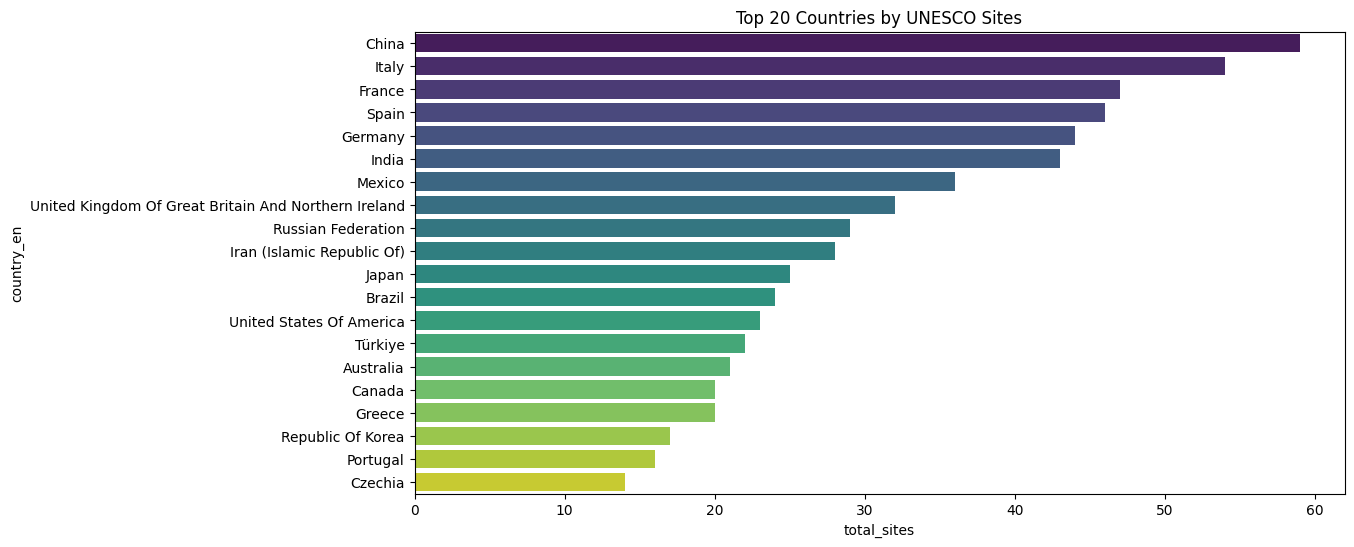

In [ ]:
plt.figure(figsize=(12, 6))
top_20 = master_df.nlargest(20, 'total_sites')
sns.barplot(x='total_sites', y='country_en', data=top_20, palette='viridis', hue='country_en', legend=False)
plt.title('Top 20 Countries by UNESCO Sites')
plt.show()

**Cell 7: Country Encoding**

In [ ]:
le = LabelEncoder()
master_df['Country_ID'] = le.fit_transform(master_df['country_en'])

**Cell 8: Feature Engineering**

In [ ]:
X = master_df[['Country_ID']]
y = master_df['total_sites']

**Cell 9: Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Cell 10: Random Forest Regressor**

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Cell 11: Gradient Boosting**

In [ ]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

**Cell 12: XGBoost (Optional)**

In [ ]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

**Cell 13: Model Evaluation**

In [ ]:
def eval_model(model, X_test, y_test):
    preds = model.predict(X_test)
    print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
    print(f"R² Score: {r2_score(y_test, preds):.2f}")
    return r2_score(y_test, preds)

print("RF Evaluation:")
eval_model(rf_model, X_test, y_test)

RF Evaluation:
MAE: 6.07
R² Score: -1.29


-1.2919083791082335

**Cell 14: Accuracy Comparison**

In [ ]:
# Compare R² scores for all models

**Cell 15: Save Best Model**

In [ ]:
joblib.dump(rf_model, 'unesco_model.pkl')
joblib.dump(le, 'country_encoder.pkl')

['country_encoder.pkl']

**Cell 16: Prediction Function**

In [ ]:
def predict_site_info(country_name):
    # Fix: Use 'country_en' instead of 'Country'
    row = master_df[master_df['country_en'] == country_name.title()].iloc[0]

    # Fix: Use the actual column names from the master_df
    print(f"Country           : {row['country_en']}")
    print(f"Total Sites       : {row['total_sites']}")
    print(f"Cultural Sites    : {row['cultural_sites']}")
    print(f"Natural Sites     : {row['natural_sites']}")
    print(f"Mixed Sites       : {row['mixed_sites']}")
    print(f"Danger Sites      : {row['in_danger_sites']}")
    return row

**Cell 17: Interactive User Input**

In [ ]:
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Defining the missing plotting function
def plot_advanced_composition(df, country_name):
    data = df[df['country_en'] == country_name].iloc[0]
    labels = ['Cultural', 'Natural', 'Mixed', 'Danger']
    values = [data['cultural_sites'], data['natural_sites'], data['mixed_sites'], data['in_danger_sites']]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['blue', 'green', 'orange', 'red'])
    plt.title(f"Site Composition: {country_name}")
    plt.ylabel("Number of Sites")
    plt.show()

def interactive_dashboard(country):
    print(f"--- Data Summary for {country} ---")
    result_data = predict_site_info(country)
    plot_advanced_composition(master_df, country)

# Fix: Use 'country_en' instead of 'Country'
dropdown = widgets.Dropdown(
    options=sorted(master_df['country_en'].unique()),
    description='Select Country:',
    style={'description_width': 'initial'}
)

interact(interactive_dashboard, country=dropdown);

interactive(children=(Dropdown(description='Select Country:', options=('Afghanistan', 'Albania', 'Albania,Aust…

**Cell 19: Top 30 UNESCO Countries**

In [ ]:
from IPython.display import display
# Corrected column name from 'Total' to 'total_sites'
display(master_df.sort_values(by='total_sites', ascending=False).head(30))

,iso_code,country_en,region_en,total_sites,cultural_sites,natural_sites,mixed_sites,in_danger_sites,first_inscribed,latest_inscribed,Country_ID
0,CN,China,Asia and the Pacific,59,40,15,4,0,1987,2025,50
1,IT,Italy,Europe and North America,54,50,4,0,0,1979,2025,107
2,FR,France,Europe and North America,47,40,6,1,0,1979,2025,80
3,ES,Spain,Europe and North America,46,42,3,1,0,1984,2023,184
4,DE,Germany,Europe and North America,44,43,1,0,0,1978,2025,86
5,IN,India,Asia and the Pacific,43,35,7,1,0,1983,2025,101
6,MX,Mexico,Latin America and the Caribbean,36,28,6,2,1,1987,2025,136
7,GB,United Kingdom Of Great Britain And Northern I...,Europe and North America,32,26,5,1,0,1986,2024,201
8,RU,Russian Federation,Europe and North America,29,20,9,0,0,1990,2025,168
9,IR,Iran (Islamic Republic Of),Asia and the Pacific,28,27,1,0,0,1979,2025,103


**Cell 20: Conclusion**

In [ ]:
print("Model Successfully Trained.")
print("Prediction Ready.")

Model Successfully Trained.
Prediction Ready.
